# SupplyPrescript
## Notebook 9: Final Performance Analysis & Business Insights

### Objective
This notebook consolidates the outputs of Notebooks 5–8 and evaluates the overall SupplyPrescript prototype.

It covers:
- Predictive model performance
- Shipment risk distribution
- Recommended actions
- Recommendation follow-through
- Operational outcomes
- Estimated versus actual costs
- Action-level performance
- Final KPIs and business insights

### Important Note
Notebook 8 uses demonstration outcome data because real manager decisions and operational outcomes are not yet available. Closed-loop metrics here must therefore be treated as prototype results.


## 9.1 Import Libraries


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")


Libraries imported successfully.


## 9.2 Define Project Paths


In [2]:
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")
MODELS_DIR = os.path.join(BASE_DIR, "models")

print("Project directory:", BASE_DIR)
print("Processed directory:", PROCESSED_DIR)
print("Models directory:", MODELS_DIR)


Project directory: c:\Users\USER\OneDrive\Desktop\VSCode\c++\SupplyPrescript
Processed directory: c:\Users\USER\OneDrive\Desktop\VSCode\c++\SupplyPrescript\data\processed
Models directory: c:\Users\USER\OneDrive\Desktop\VSCode\c++\SupplyPrescript\models


## 9.3 Load Notebook 7 Decision Results


In [3]:
DECISION_RESULTS_PATH = os.path.join(
    PROCESSED_DIR, "SupplyPrescript_decision_results.csv"
)

if not os.path.exists(DECISION_RESULTS_PATH):
    raise FileNotFoundError(
        f"File not found: {DECISION_RESULTS_PATH}. Run Notebook 7 first."
    )

decision_results = pd.read_csv(DECISION_RESULTS_PATH)

print("Decision results shape:", decision_results.shape)
display(decision_results.head())


Decision results shape: (25, 8)


,shipment_index,delay_probability,predicted_delay,risk_level,recommended_action,additional_cost,expected_delay_risk,optimization_status
0,0,0.000245,0,Low Risk,standard_shipping,0,0.000245,Optimal
1,1,0.000367,0,Low Risk,standard_shipping,0,0.000367,Optimal
2,2,0.000059,0,Low Risk,standard_shipping,0,0.000059,Optimal
3,3,0.234605,0,Low Risk,standard_shipping,0,0.234605,Optimal
4,4,0.705212,1,High Risk,standard_shipping,0,0.705212,Optimal


## 9.4 Load Notebook 8 Closed-Loop Data


In [4]:
FEEDBACK_PATH = os.path.join(
    PROCESSED_DIR, "closed_loop_feedback.csv"
)
ACTION_SUMMARY_PATH = os.path.join(
    PROCESSED_DIR, "action_performance_summary.csv"
)

if not os.path.exists(FEEDBACK_PATH):
    raise FileNotFoundError(
        f"File not found: {FEEDBACK_PATH}. Run Notebook 8 first."
    )

if not os.path.exists(ACTION_SUMMARY_PATH):
    raise FileNotFoundError(
        f"File not found: {ACTION_SUMMARY_PATH}. Run Notebook 8 first."
    )

feedback_data = pd.read_csv(FEEDBACK_PATH)
action_summary = pd.read_csv(ACTION_SUMMARY_PATH)

print("Feedback data shape:", feedback_data.shape)
print("Action summary shape:", action_summary.shape)


Feedback data shape: (25, 13)
Action summary shape: (1, 9)


## 9.5 Load Model Performance Results


In [5]:
MODEL_RESULTS_PATH = os.path.join(
    PROCESSED_DIR, "model_results.csv"
)

if os.path.exists(MODEL_RESULTS_PATH):
    model_results = pd.read_csv(MODEL_RESULTS_PATH)
    print("Model results loaded.")
    display(model_results)
else:
    model_results = pd.DataFrame()
    print(
        "model_results.csv was not found. "
        "Model-comparison charts will be skipped."
    )


model_results.csv was not found. Model-comparison charts will be skipped.


## 9.6 Overall Decision Statistics


In [6]:
total_decisions = len(feedback_data)

high_risk_count = feedback_data["risk_level"].eq("High Risk").sum()
medium_risk_count = feedback_data["risk_level"].eq("Medium Risk").sum()
low_risk_count = feedback_data["risk_level"].eq("Low Risk").sum()

print("Total decisions:", total_decisions)
print("High-risk shipments:", high_risk_count)
print("Medium-risk shipments:", medium_risk_count)
print("Low-risk shipments:", low_risk_count)


Total decisions: 25
High-risk shipments: 14
Medium-risk shipments: 0
Low-risk shipments: 11


## 9.7 Risk Distribution


In [7]:
risk_distribution = (
    feedback_data["risk_level"]
    .value_counts()
    .reindex(["Low Risk", "Medium Risk", "High Risk"], fill_value=0)
)

display(risk_distribution)


risk_level
Low Risk       11
Medium Risk     0
High Risk      14
Name: count, dtype: int64

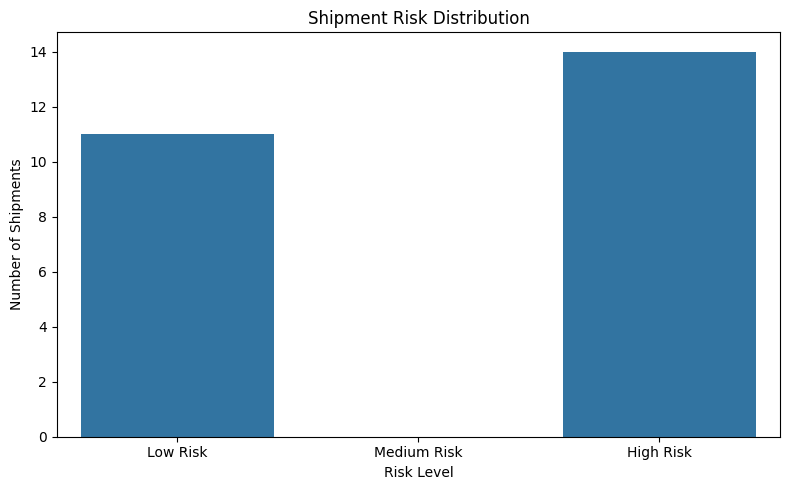

In [8]:
plt.figure(figsize=(8, 5))
sns.barplot(x=risk_distribution.index, y=risk_distribution.values)
plt.xlabel("Risk Level")
plt.ylabel("Number of Shipments")
plt.title("Shipment Risk Distribution")
plt.tight_layout()
plt.show()


## 9.8 Recommended Action Distribution


In [9]:
action_distribution = feedback_data["recommended_action"].value_counts()
display(action_distribution)


recommended_action
standard_shipping    25
Name: count, dtype: int64

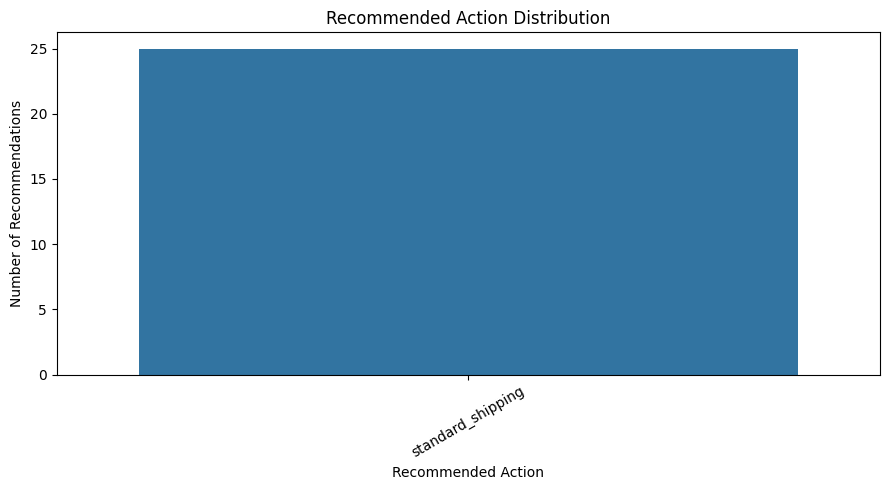

In [10]:
plt.figure(figsize=(9, 5))
sns.barplot(x=action_distribution.index, y=action_distribution.values)
plt.xlabel("Recommended Action")
plt.ylabel("Number of Recommendations")
plt.title("Recommended Action Distribution")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 9.9 Recommendation Follow-Through


In [11]:
followed = feedback_data["recommendation_followed"].sum()
not_followed = len(feedback_data) - followed
follow_through_rate = followed / len(feedback_data) * 100

print("Recommendations followed:", followed)
print("Recommendations not followed:", not_followed)
print(f"Follow-through rate: {follow_through_rate:.2f}%")


Recommendations followed: 20
Recommendations not followed: 5
Follow-through rate: 80.00%


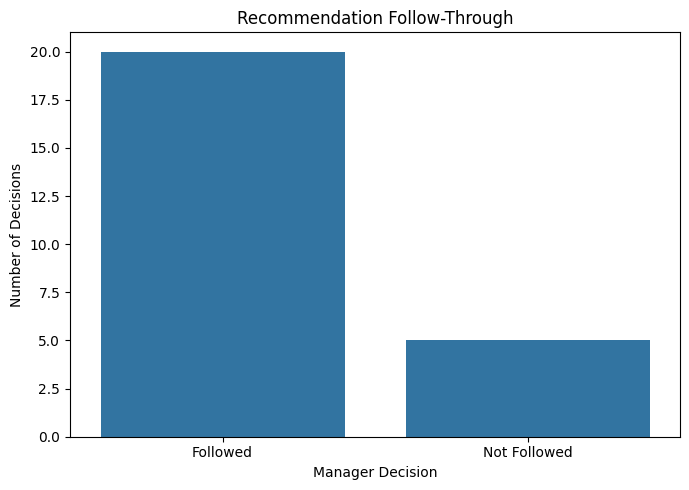

In [12]:
follow_through_data = pd.Series({
    "Followed": followed,
    "Not Followed": not_followed
})

plt.figure(figsize=(7, 5))
sns.barplot(x=follow_through_data.index, y=follow_through_data.values)
plt.xlabel("Manager Decision")
plt.ylabel("Number of Decisions")
plt.title("Recommendation Follow-Through")
plt.tight_layout()
plt.show()


## 9.10 Overall Operational Success


In [13]:
successful = feedback_data["recommendation_success"].sum()
unsuccessful = len(feedback_data) - successful
success_rate = successful / len(feedback_data) * 100

print("Successful decisions:", successful)
print("Unsuccessful decisions:", unsuccessful)
print(f"Overall success rate: {success_rate:.2f}%")


Successful decisions: 5
Unsuccessful decisions: 20
Overall success rate: 20.00%


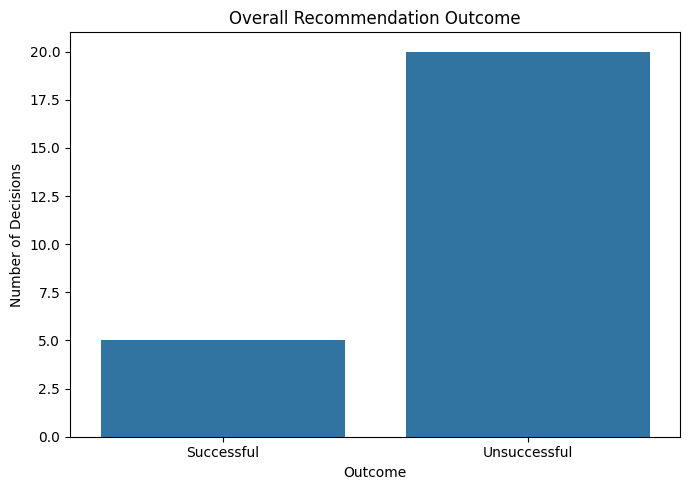

In [14]:
success_data = pd.Series({
    "Successful": successful,
    "Unsuccessful": unsuccessful
})

plt.figure(figsize=(7, 5))
sns.barplot(x=success_data.index, y=success_data.values)
plt.xlabel("Outcome")
plt.ylabel("Number of Decisions")
plt.title("Overall Recommendation Outcome")
plt.tight_layout()
plt.show()


## 9.11 Action-Level Performance


In [15]:
action_performance = action_summary.copy()
display(action_performance)


,recommended_action,recommendations,followed,successful,average_actual_delay,average_actual_cost,average_cost_difference,follow_through_rate,success_rate
0,standard_shipping,25,20,5,2.8,1268.08,1268.08,80.0,20.0


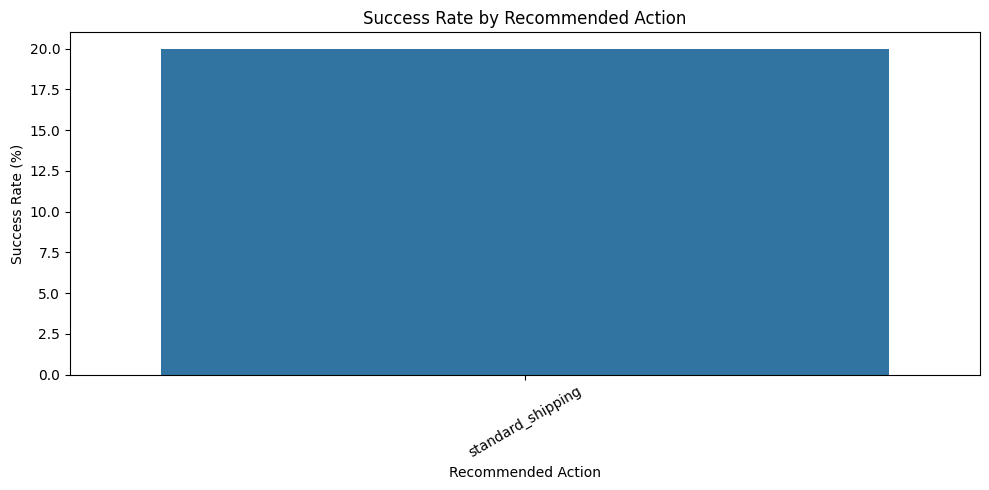

In [16]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=action_performance,
    x="recommended_action",
    y="success_rate"
)
plt.xlabel("Recommended Action")
plt.ylabel("Success Rate (%)")
plt.title("Success Rate by Recommended Action")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 9.12 Average Actual Delay by Action


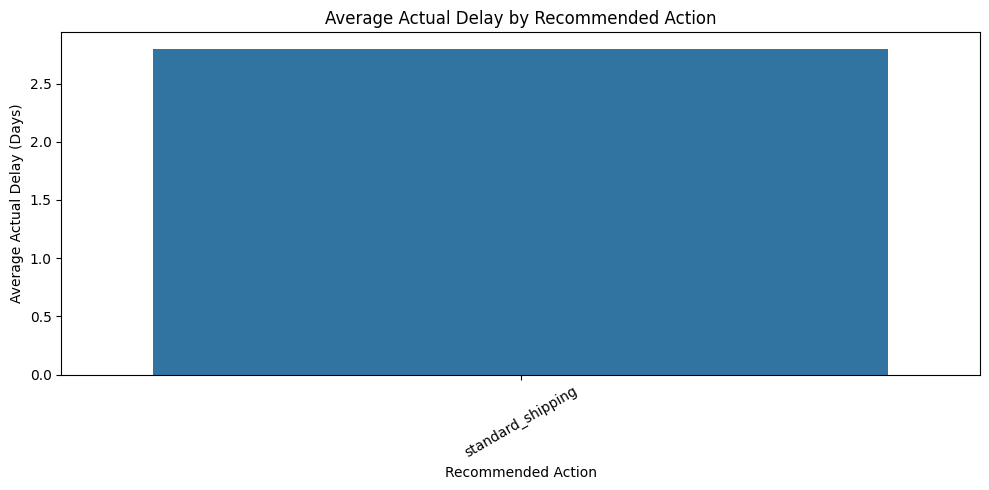

In [17]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=action_performance,
    x="recommended_action",
    y="average_actual_delay"
)
plt.xlabel("Recommended Action")
plt.ylabel("Average Actual Delay (Days)")
plt.title("Average Actual Delay by Recommended Action")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 9.13 Estimated Cost vs Actual Cost


In [18]:
cost_comparison = (
    feedback_data[
        ["recommended_action", "additional_cost", "actual_cost"]
    ]
    .groupby("recommended_action")
    .mean(numeric_only=True)
    .reset_index()
)

display(cost_comparison)


,recommended_action,additional_cost,actual_cost
0,standard_shipping,0.0,1268.08


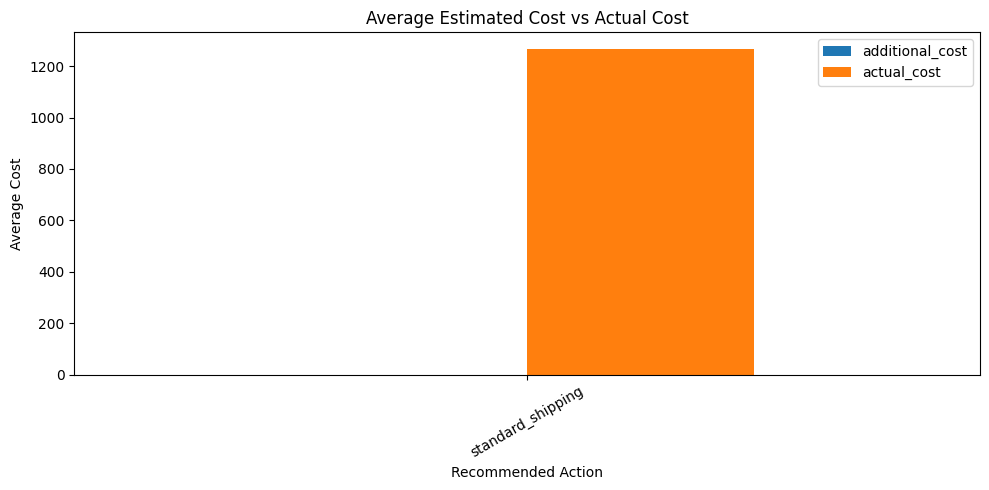

In [19]:
cost_plot = cost_comparison.set_index("recommended_action")[
    ["additional_cost", "actual_cost"]
]

cost_plot.plot(kind="bar", figsize=(10, 5))
plt.xlabel("Recommended Action")
plt.ylabel("Average Cost")
plt.title("Average Estimated Cost vs Actual Cost")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 9.14 Cost Variance Analysis


In [20]:
average_estimated_cost = feedback_data["additional_cost"].mean()
average_actual_cost = feedback_data["actual_cost"].mean()
average_cost_difference = feedback_data["cost_difference"].mean()

print(f"Average estimated cost: ${average_estimated_cost:,.2f}")
print(f"Average actual cost: ${average_actual_cost:,.2f}")
print(f"Average cost difference: ${average_cost_difference:,.2f}")


Average estimated cost: $0.00
Average actual cost: $1,268.08
Average cost difference: $1,268.08


## 9.15 Actual Delay Distribution


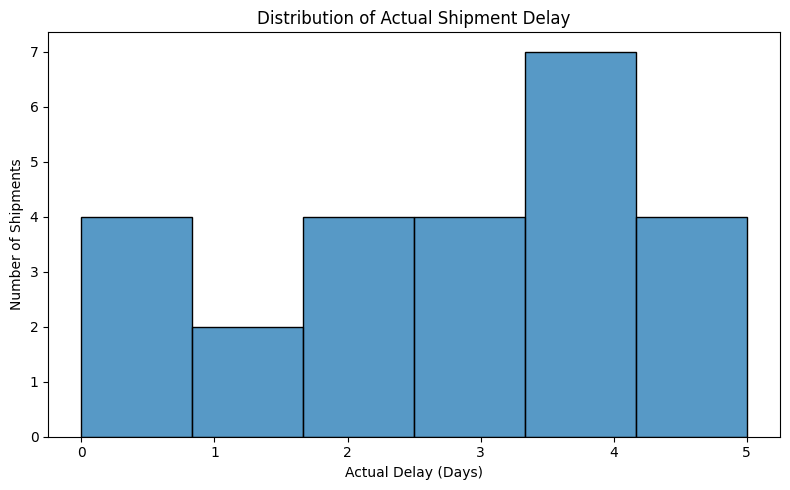

In [21]:
plt.figure(figsize=(8, 5))
sns.histplot(feedback_data["actual_delay_days"], bins=6)
plt.xlabel("Actual Delay (Days)")
plt.ylabel("Number of Shipments")
plt.title("Distribution of Actual Shipment Delay")
plt.tight_layout()
plt.show()


## 9.16 Delay Probability vs Actual Delay


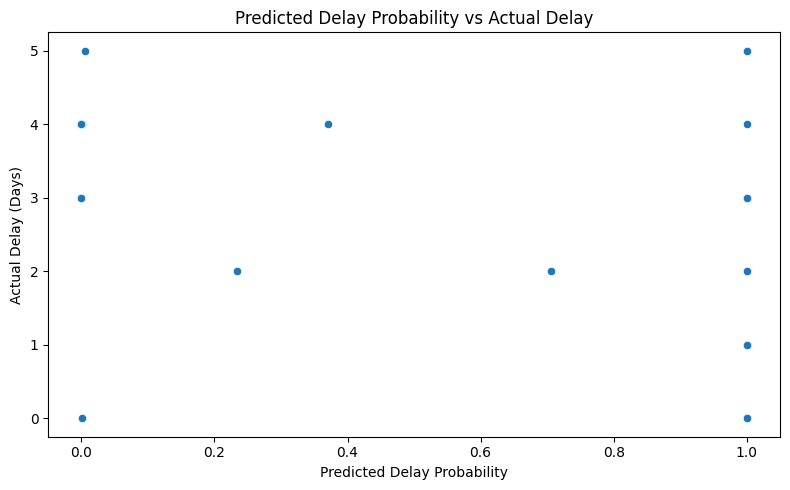

In [22]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=feedback_data,
    x="delay_probability",
    y="actual_delay_days"
)
plt.xlabel("Predicted Delay Probability")
plt.ylabel("Actual Delay (Days)")
plt.title("Predicted Delay Probability vs Actual Delay")
plt.tight_layout()
plt.show()


## 9.17 Identify High-Risk Cases Requiring Review


In [23]:
review_cases = feedback_data[
    feedback_data["risk_level"].eq("High Risk")
    & ~feedback_data["recommendation_success"]
].copy()

print("High-risk cases requiring review:", len(review_cases))
display(review_cases.head(10))


High-risk cases requiring review: 9


,shipment_index,delay_probability,risk_level,recommended_action,manager_decision,additional_cost,actual_cost,cost_difference,expected_delay_risk,actual_delay_days,outcome_status,recommendation_followed,recommendation_success
4,4,0.705212,High Risk,standard_shipping,standard_shipping,0,774,774,0.705212,2,Delayed,True,False
11,11,0.999980,High Risk,standard_shipping,standard_shipping,0,2434,2434,0.999980,5,Delayed,True,False
14,14,0.999680,High Risk,standard_shipping,standard_shipping,0,1527,1527,0.999680,4,Delayed,True,False
16,16,0.999929,High Risk,standard_shipping,standard_shipping,0,2033,2033,0.999929,3,Delayed,True,False
18,18,0.999894,High Risk,standard_shipping,standard_shipping,0,418,418,0.999894,5,Delayed,True,False
19,19,0.999911,High Risk,standard_shipping,standard_shipping,0,0,0,0.999911,2,Delayed,True,False
20,20,0.999649,High Risk,standard_shipping,air_freight,0,2883,2883,0.999649,3,Delayed,False,False
21,21,0.999725,High Risk,standard_shipping,standard_shipping,0,783,783,0.999725,2,Delayed,True,False
23,23,0.999882,High Risk,standard_shipping,standard_shipping,0,1712,1712,0.999882,5,Delayed,True,False


## 9.18 Identify Best-Performing Action


In [24]:
if not action_performance.empty:
    best_action_row = action_performance.loc[
        action_performance["success_rate"].idxmax()
    ]
    print("Best-performing action:", best_action_row["recommended_action"])
    print(f"Success rate: {best_action_row['success_rate']:.2f}%")
    print(
        f"Average actual delay: "
        f"{best_action_row['average_actual_delay']:.2f} days"
    )
else:
    print("No action-level performance data available.")


Best-performing action: standard_shipping
Success rate: 20.00%
Average actual delay: 2.80 days


## 9.19 Identify Highest-Cost Action


In [25]:
if not action_performance.empty:
    highest_cost_row = action_performance.loc[
        action_performance["average_actual_cost"].idxmax()
    ]
    print(
        "Highest average-cost action:",
        highest_cost_row["recommended_action"]
    )
    print(
        f"Average actual cost: "
        f"${highest_cost_row['average_actual_cost']:,.2f}"
    )
else:
    print("No action-level cost data available.")


Highest average-cost action: standard_shipping
Average actual cost: $1,268.08


## 9.20 Model Performance Comparison


In [26]:
if not model_results.empty and "Model" in model_results.columns:
    metrics = ["Accuracy", "Precision", "Recall", "F1"]
    available_metrics = [
        metric for metric in metrics
        if metric in model_results.columns
    ]

    if available_metrics:
        model_plot = model_results.set_index("Model")[available_metrics]
        model_plot.plot(kind="bar", figsize=(10, 6))
        plt.xlabel("Model")
        plt.ylabel("Score")
        plt.title("Machine Learning Model Performance")
        plt.ylim(0, 1)
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()
    else:
        print("No expected performance metrics found.")
else:
    print(
        "Skipping model comparison because model_results.csv "
        "is unavailable."
    )


Skipping model comparison because model_results.csv is unavailable.


## 9.21 Create Final KPI Table


In [27]:
final_kpis = pd.DataFrame({
    "KPI": [
        "Total Decisions",
        "High-Risk Shipments",
        "Medium-Risk Shipments",
        "Low-Risk Shipments",
        "Recommendation Follow-Through Rate (%)",
        "Overall Success Rate (%)",
        "Average Estimated Cost",
        "Average Actual Cost",
        "Average Cost Difference",
        "Average Actual Delay (Days)"
    ],
    "Value": [
        total_decisions,
        high_risk_count,
        medium_risk_count,
        low_risk_count,
        follow_through_rate,
        success_rate,
        average_estimated_cost,
        average_actual_cost,
        average_cost_difference,
        feedback_data["actual_delay_days"].mean()
    ]
})

display(final_kpis)


,KPI,Value
0,Total Decisions,25.00
1,High-Risk Shipments,14.00
2,Medium-Risk Shipments,0.00
3,Low-Risk Shipments,11.00
4,Recommendation Follow-Through Rate (%),80.00
5,Overall Success Rate (%),20.00
6,Average Estimated Cost,0.00
7,Average Actual Cost,1268.08
8,Average Cost Difference,1268.08
9,Average Actual Delay (Days),2.80


## 9.22 Generate Business Insights


In [28]:
insights = []

if total_decisions > 0:
    high_risk_percentage = high_risk_count / total_decisions * 100
    insights.append(
        f"{high_risk_percentage:.2f}% of evaluated shipments "
        "were classified as High Risk."
    )

if not action_distribution.empty:
    most_recommended_action = action_distribution.idxmax()
    insights.append(
        f"The most frequently recommended action was "
        f"'{most_recommended_action}'."
    )

insights.append(
    f"Recommendation follow-through was "
    f"{follow_through_rate:.2f}% in the prototype feedback data."
)

insights.append(
    f"The prototype overall recommendation success rate was "
    f"{success_rate:.2f}%."
)

insights.append(
    f"The average difference between estimated and actual "
    f"operational cost was ${average_cost_difference:,.2f}."
)

if not review_cases.empty:
    insights.append(
        f"{len(review_cases)} high-risk unsuccessful cases "
        "were identified for further review."
    )

print("BUSINESS INSIGHTS")
print("=================")
for number, insight in enumerate(insights, start=1):
    print(f"{number}. {insight}")


BUSINESS INSIGHTS
1. 56.00% of evaluated shipments were classified as High Risk.
2. The most frequently recommended action was 'standard_shipping'.
3. Recommendation follow-through was 80.00% in the prototype feedback data.
4. The prototype overall recommendation success rate was 20.00%.
5. The average difference between estimated and actual operational cost was $1,268.08.
6. 9 high-risk unsuccessful cases were identified for further review.


## 9.23 Save Final KPI Report


In [29]:
KPI_PATH = os.path.join(
    PROCESSED_DIR, "SupplyPrescript_final_KPIs.csv"
)

final_kpis.to_csv(KPI_PATH, index=False)

print("Final KPI report saved to:")
print(KPI_PATH)


Final KPI report saved to:
c:\Users\USER\OneDrive\Desktop\VSCode\c++\SupplyPrescript\data\processed\SupplyPrescript_final_KPIs.csv


## 9.24 Save Business Insights


In [30]:
INSIGHTS_PATH = os.path.join(
    PROCESSED_DIR, "SupplyPrescript_business_insights.txt"
)

with open(INSIGHTS_PATH, "w", encoding="utf-8") as file:
    file.write(
        "SUPPLYPRESCRIPT BUSINESS INSIGHTS\n"
        "================================\n\n"
    )
    for number, insight in enumerate(insights, start=1):
        file.write(f"{number}. {insight}\n")

print("Business insights saved to:")
print(INSIGHTS_PATH)


Business insights saved to:
c:\Users\USER\OneDrive\Desktop\VSCode\c++\SupplyPrescript\data\processed\SupplyPrescript_business_insights.txt


## 9.25 Final Validation


In [31]:
output_paths = [
    KPI_PATH,
    INSIGHTS_PATH,
    DECISION_RESULTS_PATH,
    FEEDBACK_PATH,
    ACTION_SUMMARY_PATH
]

for path in output_paths:
    print(
        f"{os.path.basename(path)} -> "
        f"{'Available' if os.path.exists(path) else 'Missing'}"
    )


SupplyPrescript_final_KPIs.csv -> Available
SupplyPrescript_business_insights.txt -> Available
SupplyPrescript_decision_results.csv -> Available
closed_loop_feedback.csv -> Available
action_performance_summary.csv -> Available


# Final Summary

Notebook 9 provides the final analytical evaluation of the SupplyPrescript prototype.

### Predictive Layer
Machine learning estimates shipment delay risk.

### Prescriptive Layer
The optimization engine recommends an operational response under business constraints.

### Closed-Loop Layer
Recommendations, manager decisions, and operational outcomes are recorded for future improvement.

### Final Analytical Layer
This notebook converts those outputs into:
- KPIs
- Performance comparisons
- Action-level analysis
- Cost analysis
- Risk analysis
- Review cases
- Business insights

### Important Limitation
The closed-loop outcome values currently used in Notebook 8 are demonstration values. Therefore, closed-loop success, cost, and outcome statistics here are prototype metrics rather than validated production performance.

### Project Outcome
The analytical prototype now follows:

**Predict → Prescribe → Decide → Observe → Evaluate → Improve**

The next stage can be the SupplyPrescript application/backend, where these components are connected to a user interface and persistent database.


# End of Notebook 9
